In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:
import numpy as np
import tensorflow.keras as k
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

In [3]:
# load the dataset in batches
IMG_SIZE =(128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/brain-tumor-mri-dataset/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/brain-tumor-mri-dataset/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
def normalize_and_rgb(image, label):
    image = tf.image.per_image_standardization(image)
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)
    return image, label

train_ds = train_ds.map(normalize_and_rgb)
test_ds = test_ds.map(normalize_and_rgb)

In [5]:
for images, labels in train_ds:
    print(images.shape)
    print(labels.shape)
    break

(32, 128, 128, 3)
(32, 4)


In [6]:
for images, labels in train_ds:
    print(np.max(images))
    print(np.min(images))
    break

8.071932
-1.5642043


In [7]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [8]:
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
for layer in base_model.layers[:150]:
    layer.trainable = False
for layer in base_model.layers[150:]:
    layer.trainable = True

In [10]:
inputs = layers.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,306,052 (27.87 MB)

 Trainable params: 5,719,236 (21.82 MB)

 Non-trainable params: 1,586,816 (6.05 MB)

In [11]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
# define early stopping
callback_list = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [13]:
# training the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[callback_list]
)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 223ms/step - accuracy: 0.6672 - loss: 0.9941 - val_accuracy: 0.8085 - val_loss: 0.5840
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.8956 - loss: 0.2909 - val_accuracy: 0.9306 - val_loss: 0.2131
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 168ms/step - accuracy: 0.9265 - loss: 0.2091 - val_accuracy: 0.9291 - val_loss: 0.2090
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 173ms/step - accuracy: 0.9441 - loss: 0.1620 - val_accuracy: 0.9420 - val_loss: 0.1860
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 171ms/step - accuracy: 0.9548 - loss: 0.1299 - val_accuracy: 0.9314 - val_loss: 0.1661
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.9731 - loss: 0.0794 - val_accuracy: 0.9634 - val_loss: 0.1241
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step - accuracy: 0.9687 - loss: 0.0954 - val_accuracy: 0.9664 - val_loss: 0.1138
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 174ms/step - accuracy: 0.9743 - loss: 0

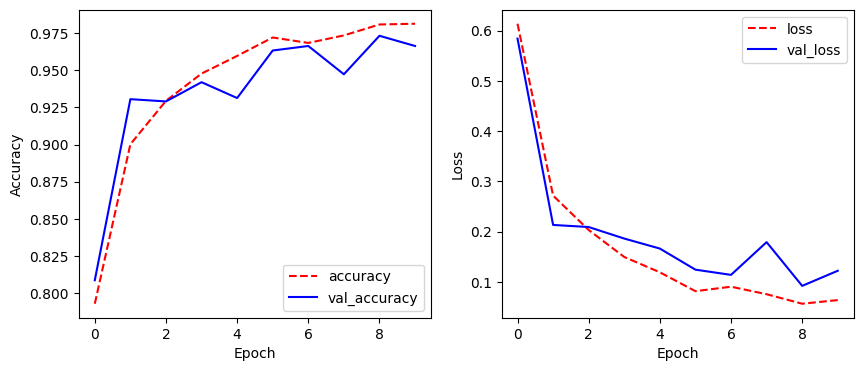

In [14]:
# Visualize the accuracy, val_accuracy, loss and val_loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy', linestyle='--', color='red')
plt.plot(history.history['val_accuracy'], label='val_accuracy', linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss', linestyle='--', color='red')
plt.plot(history.history['val_loss'], label='val_loss', linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os

SAVE_DIR = "/content/drive/MyDrive/BrainTumorModel"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(f"{SAVE_DIR}/dense121_brain_tumor_model.keras")

**Test the model on another dataset (SARTAJ)**

In [17]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/BrainTumorModel/dense121_brain_tumor_model.keras"
)

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Path to dataset files: /kaggle/input/brain-tumor-classification-mri


In [19]:
# Load the testing dataset
test_sartaj_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/brain-tumor-classification-mri/Testing",
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    shuffle=False,
    class_names=[
        "glioma_tumor",
        "meningioma_tumor",
        "no_tumor",
        "pituitary_tumor"
    ]
)

Found 394 files belonging to 4 classes.


In [20]:
# normalization + grey scale to RGB
def normalize_and_rgb(image, label):
    image = tf.image.per_image_standardization(image)
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)
    return image, label

test_sartaj_ds = test_sartaj_ds.map(normalize_and_rgb)

In [21]:
# testing the model
loss, acc = model.evaluate(test_sartaj_ds)
print(f"Sartaj Test Accuracy: {acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.5982 - loss: 3.1614
Sartaj Test Accuracy: 0.7792


In [22]:
# confusion matrix + classification report
y_true = []
y_pred = []

for images, labels in test_sartaj_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_display = ["glioma", "meningioma", "notumor", "pituitary"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_display))


[[ 30  39  22   9]
 [  0 115   0   0]
 [  2   0 103   0]
 [  0   7   8  59]]
              precision    recall  f1-score   support

      glioma       0.94      0.30      0.45       100
  meningioma       0.71      1.00      0.83       115
     notumor       0.77      0.98      0.87       105
   pituitary       0.87      0.80      0.83        74

    accuracy                           0.78       394
   macro avg       0.82      0.77      0.75       394
weighted avg       0.82      0.78      0.75       394



In [ ]:
import gradio as gr
from PIL import Image

# -----------------------------
# Configuration
# -----------------------------
IMG_SIZE = (128, 128)
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/BrainTumorModel/dense121_brain_tumor_model.keras"
)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# -----------------------------
# Preprocessing (same as training)
# -----------------------------
def preprocess_image(image: Image.Image):
    image = image.resize(IMG_SIZE)
    image = np.array(image)

    # Grayscale → RGB
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)

    image = tf.convert_to_tensor(image, dtype=tf.float32)

    # Per-image standardization
    image = tf.image.per_image_standardization(image)

    image = tf.expand_dims(image, axis=0)
    return image

# -----------------------------
# Prediction function
# -----------------------------
def predict_mri(image):
    image = Image.fromarray(image).convert("L")
    processed_image = preprocess_image(image)

    preds = model.predict(processed_image)[0]

    results = {cls: float(prob) for cls, prob in zip(CLASS_NAMES, preds)}

    predicted_class = CLASS_NAMES[np.argmax(preds)]
    confidence = np.max(preds)

    return predicted_class, confidence, results

# -----------------------------
# Gradio Interface
# -----------------------------
interface = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(type="numpy", label="Upload MRI Image"),
    outputs=[
        gr.Label(label="Predicted Tumor Type"),
        gr.Number(label="Confidence"),
        gr.JSON(label="Class Probabilities")
    ],
    title="Brain Tumor MRI Classification",
    description=(
        "Upload a brain MRI image. "
        "The model will classify it as Glioma, Meningioma, Pituitary tumor, or No Tumor."
    ),
    allow_flagging="never"
)

interface.launch(debug=True)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dd5fe1e0e8fb5190f4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
